## **1. Business Problem & Dataset Overview**
Aerofit is a leading brand in fitness equipment offering treadmills, exercise bikes, gym equipment, and fitness accessories.
The market research team wants to identify the characteristics of target customers for each treadmill model to improve product recommendations for new customers.

 **Product Portfolio**

**KP281**

Entry Level · $1,500

✔ Basic features

✔ Suitable for beginners

✔ Budget-friendly

**KP481**

Mid Level · $1,750

✔ Enhanced features

✔ Mid-range runners

✔ Value for money

**KP781**

Advanced · $2,500

✔ Premium features

✔ Serious fitness users

✔ High performance


**Dataset Description**

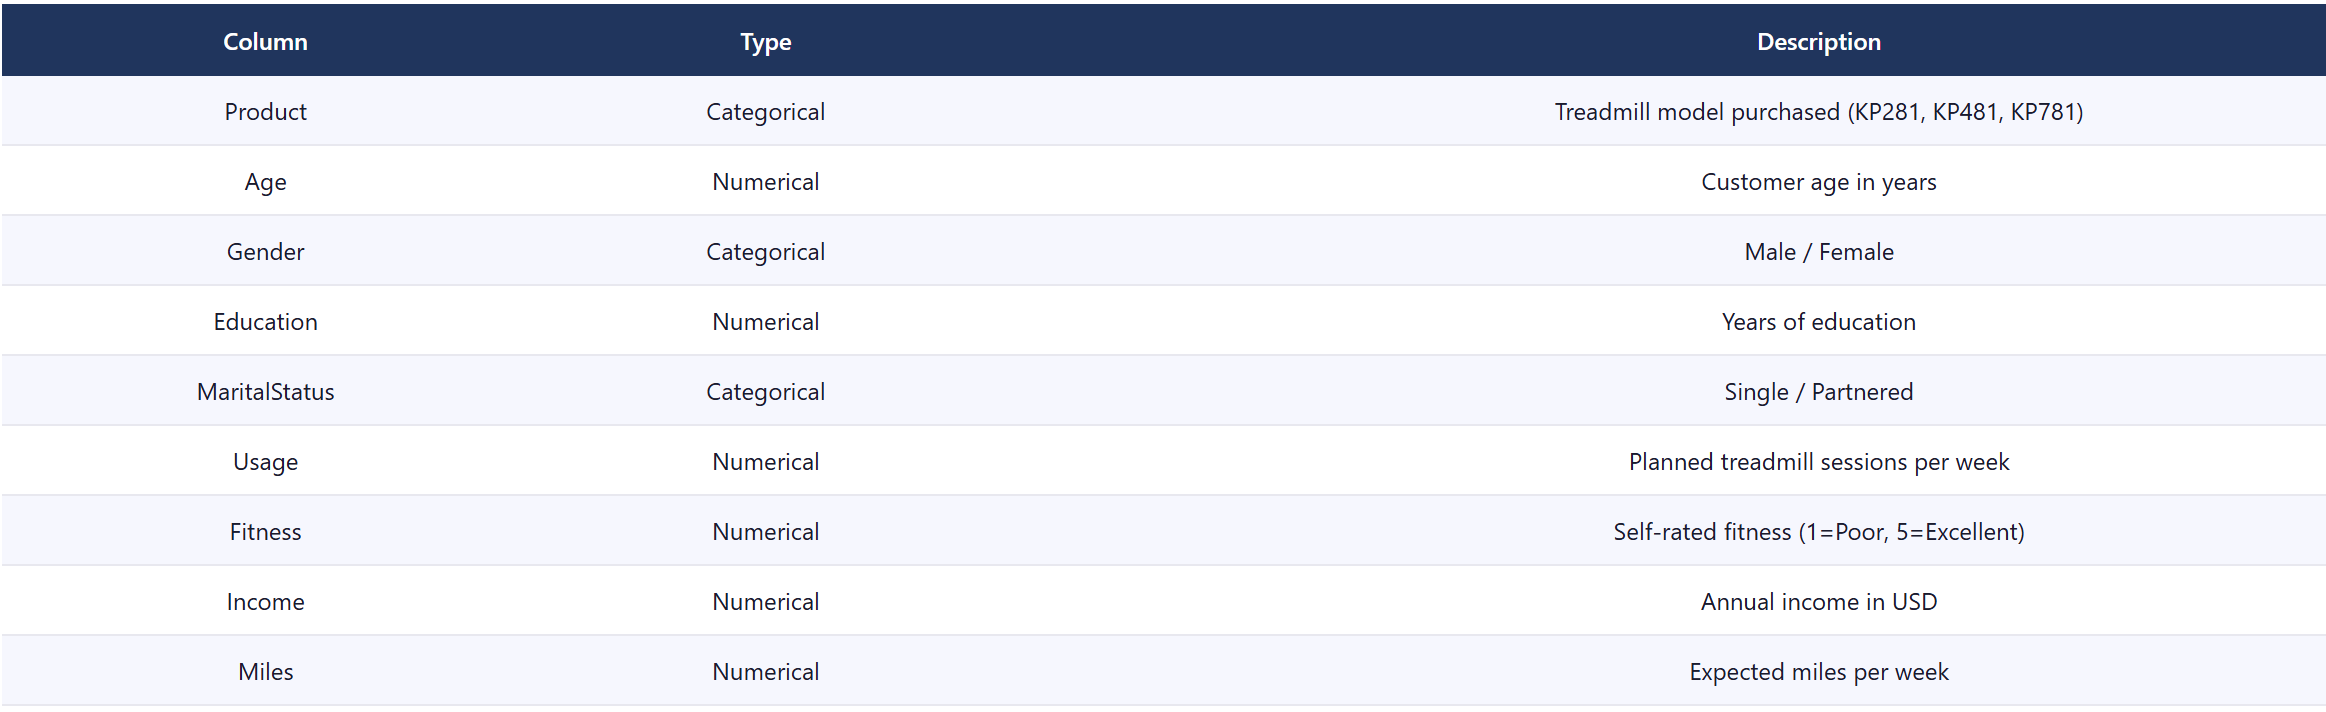


**Objective**

Perform descriptive analytics to build a customer profile for each treadmill product using charts, contingency tables, and probability analysis. Use these insights to provide actionable recommendations to Aerofit's marketing and sales teams.

## **2. Data Structure & Basic Analysis**


**2.1 Loading & Inspecting Data**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749
To: /content/aerofit_treadmill.csv?1639992749
100% 7.28k/7.28k [00:00<00:00, 24.7MB/s]


In [ ]:
data = pd.read_csv("aerofit_treadmill.csv?1639992749")
data.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
data.shape

(180, 9)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
data.nunique()

,0
Product,3
Age,32
Gender,2
Education,8
MaritalStatus,2
Usage,6
Fitness,5
Income,62
Miles,37


In [ ]:
cat_cols = ['Product', 'Gender', 'MaritalStatus']
for col in cat_cols:
    data[col] = data[col].astype('category')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Product        180 non-null    category
 1   Age            180 non-null    int64   
 2   Gender         180 non-null    category
 3   Education      180 non-null    int64   
 4   MaritalStatus  180 non-null    category
 5   Usage          180 non-null    int64   
 6   Fitness        180 non-null    int64   
 7   Income         180 non-null    int64   
 8   Miles          180 non-null    int64   
dtypes: category(3), int64(6)
memory usage: 9.5 KB


In [ ]:
data.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


✅ Insight:

The dataset has 180 complete records with zero missing values. Three columns (Product, Gender, MaritalStatus) are categorical and were converted to category dtype for memory efficiency.

**2.3 Descriptive Statistics**

In [ ]:
data.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


✅ Key Observations:

• Average customer is ~29 years old with mean income ~$53000.

• Most customers plan to use the treadmill 3 times/week with fitness rating of 3/5 — moderate engagement.

• Income has a wide range (29K-104K) indicating very diverse customer segments.

• Miles has max=360 vs mean=103.19 — right-skewed distribution with outliers at the high end.

## **3. Outlier Detection & Treatment**

**3.1 Boxplot Visualization**

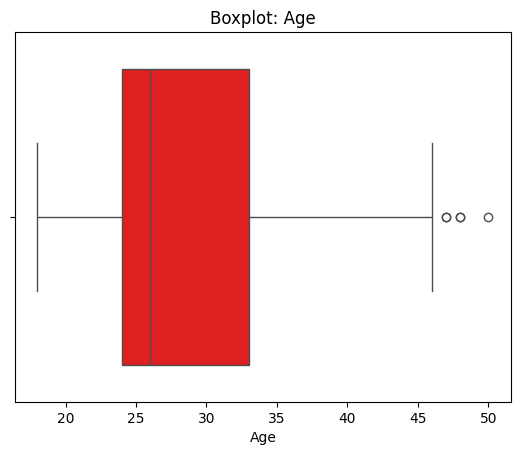

In [ ]:
sns.boxplot(x=data['Age'], color='red')
plt.title('Boxplot: Age')
plt.show()

In [ ]:
Q1_age = data["Age"].quantile(0.25)
Q3_age = data["Age"].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_bound = Q1_age - 1.5 * IQR_age
upper_bound = Q3_age + 1.5 * IQR_age
data[data["Age"] > upper_bound]

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
78,KP281,47,Male,16,Partnered,4,3,56850,94
79,KP281,50,Female,16,Partnered,3,3,64809,66
139,KP481,48,Male,16,Partnered,2,3,57987,64
178,KP781,47,Male,18,Partnered,4,5,104581,120
179,KP781,48,Male,18,Partnered,4,5,95508,180


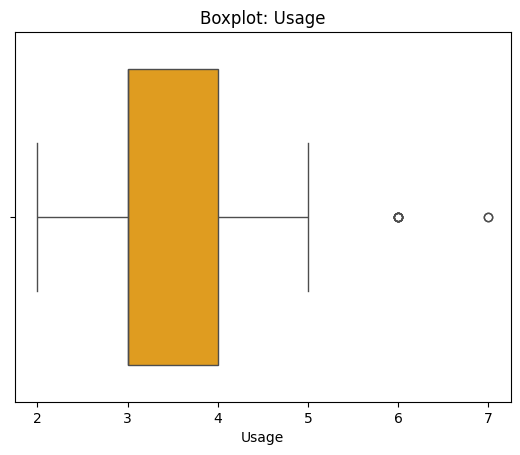

In [ ]:
sns.boxplot(x=data['Usage'], color='orange')
plt.title('Boxplot: Usage')
plt.show()

In [ ]:
Q1_Usage = data["Usage"].quantile(0.25)
Q3_Usage = data["Usage"].quantile(0.75)
IQR_Usage = Q3_Usage - Q1_Usage
upper_bound_Usage = Q3_Usage + 1.5 * IQR_Usage
lower_bound_Usage = Q1_Usage - 1.5 * IQR_Usage
data[data['Usage'] > upper_bound_Usage]

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
154,KP781,25,Male,18,Partnered,6,4,70966,180
155,KP781,25,Male,18,Partnered,6,5,75946,240
162,KP781,28,Female,18,Partnered,6,5,92131,180
163,KP781,28,Male,18,Partnered,7,5,77191,180
164,KP781,28,Male,18,Single,6,5,88396,150
166,KP781,29,Male,14,Partnered,7,5,85906,300
167,KP781,30,Female,16,Partnered,6,5,90886,280
170,KP781,31,Male,16,Partnered,6,5,89641,260
175,KP781,40,Male,21,Single,6,5,83416,200


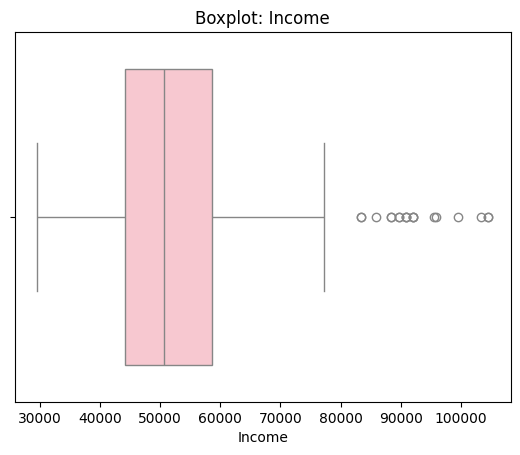

In [ ]:
sns.boxplot(x=data['Income'], color='pink')
plt.title('Boxplot: Income')
plt.show()

In [ ]:
Q1_Income = data["Income"].quantile(0.25)
Q3_Income = data["Income"].quantile(0.75)
IQR_Income = Q3_Income - Q1_Income
upper_bound_Income = Q3_Income + 1.5 * IQR_Income
lower_bound_Income = Q1_Income - 1.5 * IQR_Income
data[data['Income'] > upper_bound_Income]

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
159,KP781,27,Male,16,Partnered,4,5,83416,160
160,KP781,27,Male,18,Single,4,3,88396,100
161,KP781,27,Male,21,Partnered,4,4,90886,100
162,KP781,28,Female,18,Partnered,6,5,92131,180
164,KP781,28,Male,18,Single,6,5,88396,150
166,KP781,29,Male,14,Partnered,7,5,85906,300
167,KP781,30,Female,16,Partnered,6,5,90886,280
168,KP781,30,Male,18,Partnered,5,4,103336,160
169,KP781,30,Male,18,Partnered,5,5,99601,150
170,KP781,31,Male,16,Partnered,6,5,89641,260


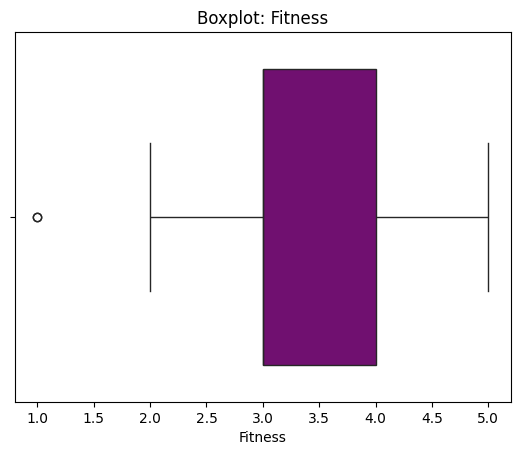

In [ ]:
sns.boxplot(x=data['Fitness'], color='purple')
plt.title('Boxplot: Fitness')
plt.show()

In [ ]:
Q1_fitness = data["Fitness"].quantile(0.25)
Q3_fitness = data["Fitness"].quantile(0.75)
IQR_fitness = Q3_fitness - Q1_fitness
upper_bound_fitness = Q3_fitness + 1.5 * IQR_fitness
lower_bound_fitness = Q1_fitness - 1.5 * IQR_fitness
data[data['Fitness'] < lower_bound_fitness]

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
14,KP281,23,Male,16,Partnered,3,1,38658,47
117,KP481,31,Female,18,Single,2,1,65220,21


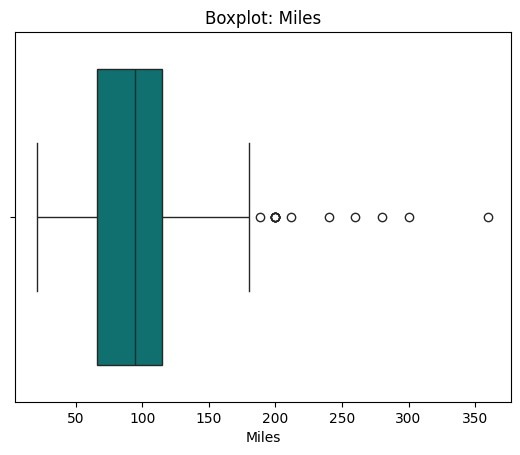

In [ ]:
sns.boxplot(x=data['Miles'], color='teal')
plt.title('Boxplot: Miles')
plt.show()

In [ ]:
Q1_miles = data["Miles"].quantile(0.25)
Q3_miles = data["Miles"].quantile(0.75)
IQR_miles = Q3_miles - Q1_miles
upper_bound_miles = Q3_miles + 1.5 * IQR_miles
lower_bound_miles = Q1_miles - 1.5 * IQR_miles
data[data['Miles'] > upper_bound_miles]

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
23,KP281,24,Female,16,Partnered,5,5,44343,188
84,KP481,21,Female,14,Partnered,5,4,34110,212
142,KP781,22,Male,18,Single,4,5,48556,200
148,KP781,24,Female,16,Single,5,5,52291,200
152,KP781,25,Female,18,Partnered,5,5,61006,200
155,KP781,25,Male,18,Partnered,6,5,75946,240
166,KP781,29,Male,14,Partnered,7,5,85906,300
167,KP781,30,Female,16,Partnered,6,5,90886,280
170,KP781,31,Male,16,Partnered,6,5,89641,260
171,KP781,33,Female,18,Partnered,4,5,95866,200


**3.3 Outlier Treatment — np.clip() at 5th–95th Percentile**

In [ ]:
for col in ['Age', 'Usage', 'Fitness', 'Income', 'Miles']:
    p5  = data[col].quantile(0.05)
    p95 = data[col].quantile(0.95)
    data[col] = np.clip(data[col], p5, p95)
    print(f"{col}: clipped to [{p5:.1f}, {p95:.1f}]")

Age: clipped to [20.0, 43.0]
Usage: clipped to [2.0, 5.0]
Fitness: clipped to [2.0, 5.0]
Income: clipped to [34053.2, 90948.2]
Miles: clipped to [47.0, 200.0]


⚠️ Important Outlier Notes:

• Age outliers: 5 customers aged 47–50 detected. All partnered males, mostly buying KP781/KP281.

• Income outliers: High-income customers (>$80K) are mostly KP781 buyers — these are genuine premium buyers, not data errors.

• Miles outliers: 200–360 miles/week indicates a niche power-user segment exclusively buying KP781.

• Usage outliers: 6–7 sessions/week users are fitness enthusiasts — prime KP781 candidates.

## **4.Univariate & Bivariate Analysis**

**4.1 Product Distribution**

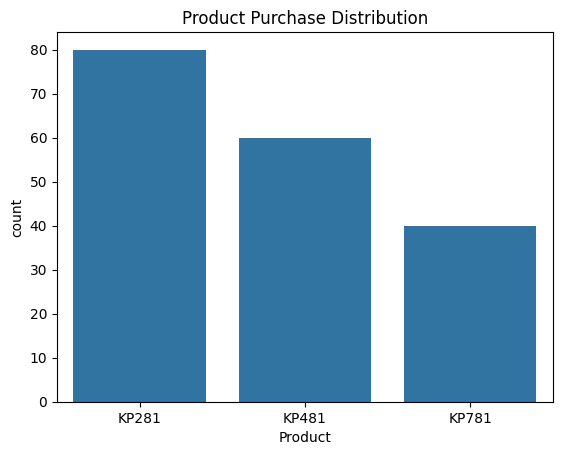

In [ ]:
sns.countplot(x= 'Product', data = data)
plt.title('Product Purchase Distribution')
plt.show()


✅ Insight:

KP281 dominates purchases. KP781 has the lowest volume but highest price point — quality over quantity in revenue contribution.

**4.2 Gender and MaritalStatus**

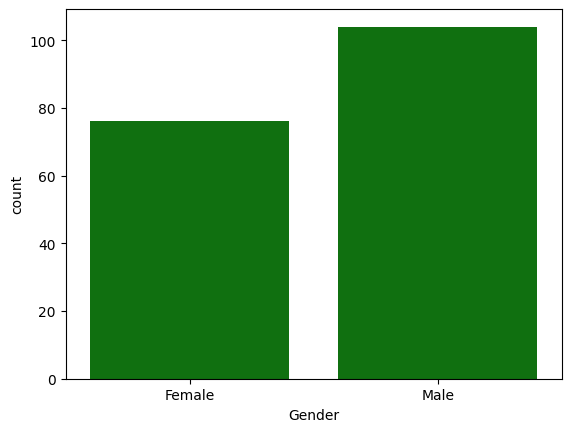

In [ ]:
sns.countplot(x= 'Gender', data = data, color='g')
plt.show()

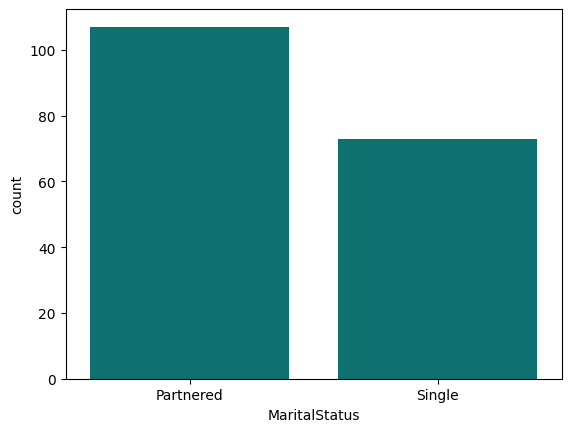

In [ ]:
sns.countplot(x= 'MaritalStatus', data = data, color= 'teal')
plt.show()

**4.3 Income Distribution by Product**

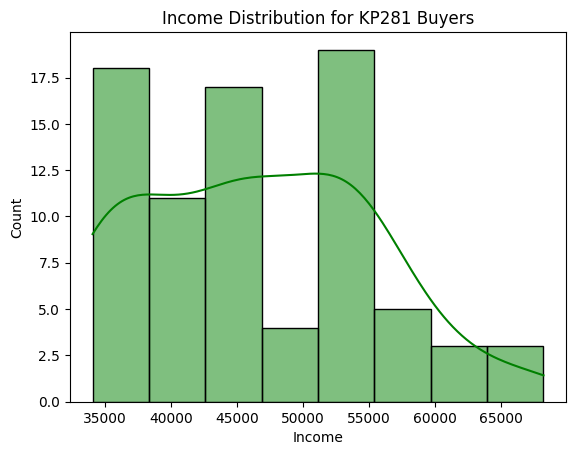

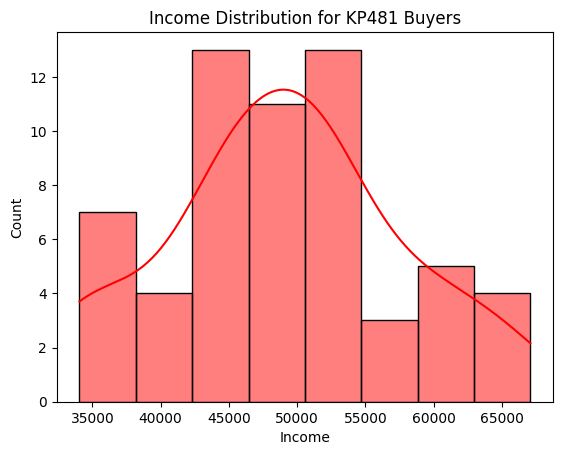

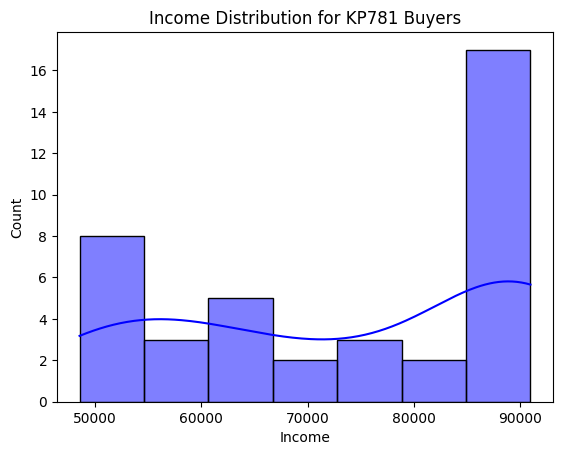

In [ ]:
for product, color in zip(['KP281','KP481','KP781'], ['green','red','blue']):
    sns.histplot(data=data[data['Product']==product], x='Income', kde=True, color=color)
    plt.title(f'Income Distribution for {product} Buyers')
    plt.show()

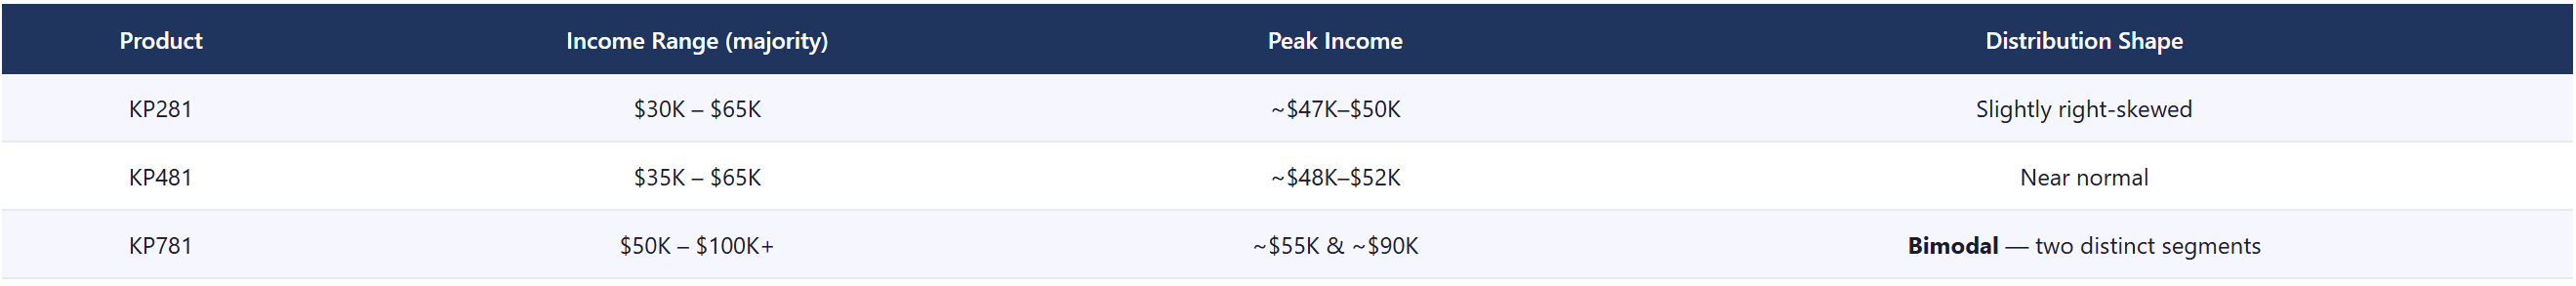

**4.4 Age Group Analysis**

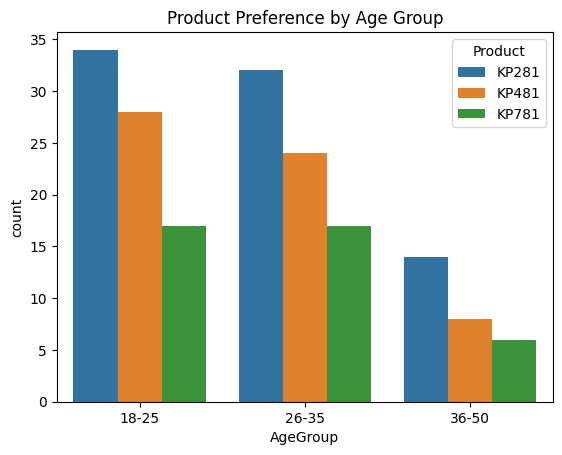

In [ ]:
data['AgeGroup'] = pd.cut(data['Age'], bins=[17,25,35,50], labels=['18-25','26-35','36-50'])
sns.countplot(x='AgeGroup', hue='Product', data=data)
plt.title('Product Preference by Age Group')
plt.show()

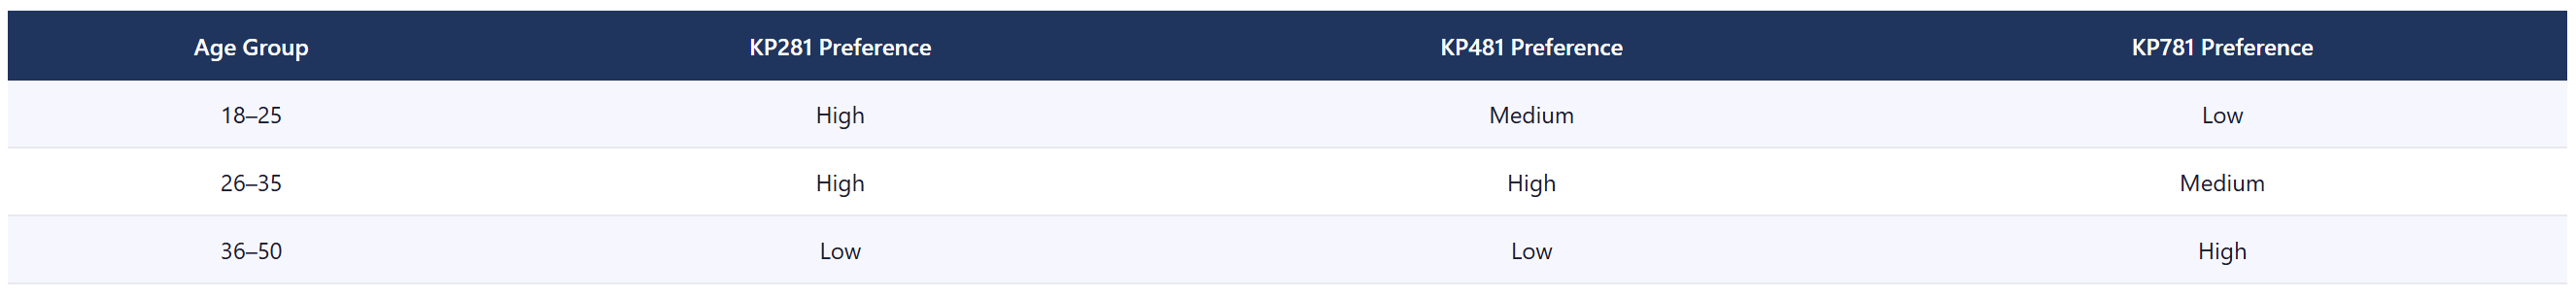

## **5. Marginal & Conditional Probability**

 **5.1 Marginal Probability**

In [ ]:
data['Product'].value_counts(normalize=True)

,proportion
Product,
KP281,0.444444
KP481,0.333333
KP781,0.222222


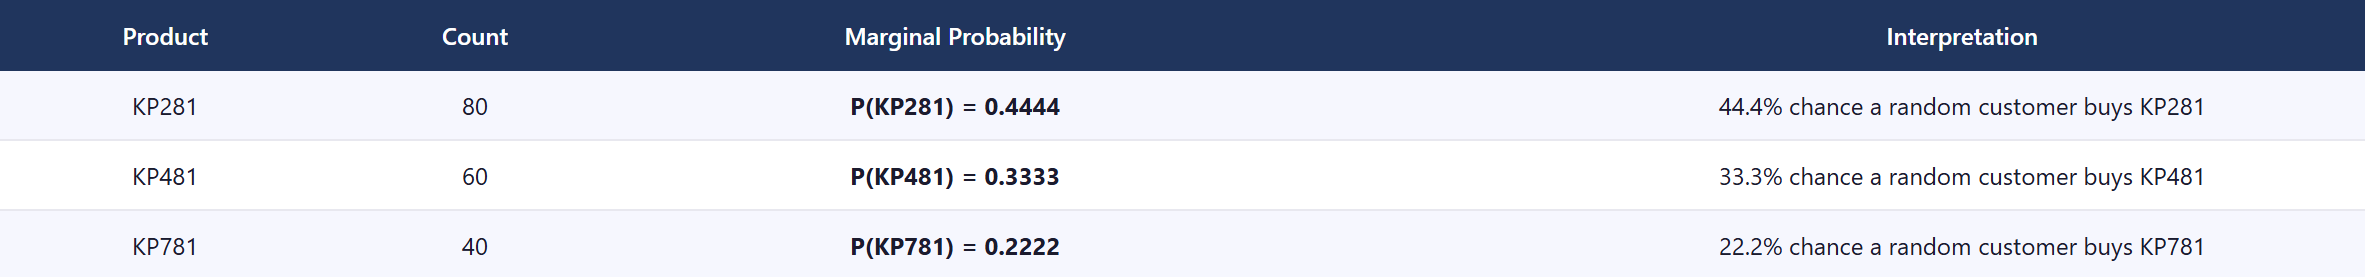

**5.2 Contingency Table — Gender × Product**

In [ ]:
count_table = pd.crosstab(data['Gender'], data['Product'])
count_table

Product,KP281,KP481,KP781
Gender,,,
Female,40,29,7
Male,40,31,33


In [ ]:
gender_prob = pd.crosstab(
    data['Gender'],
    data['Product'],
    normalize='index'
)

gender_prob

Product,KP281,KP481,KP781
Gender,,,
Female,0.526316,0.381579,0.092105
Male,0.384615,0.298077,0.317308


✅ Key Conditional Probability Findings:

• P(KP781 | Female) = 9.2% — Only 1 in 11 female customers buys the premium model

• P(KP781 | Male) = 31.7% — Nearly 1 in 3 male customers buys the premium model

• Males are 3.4× more likely than females to purchase KP781

• P(KP281 | Female) = 52.6% — More than half of all female buyers choose entry-level

**5.3 Contingency Table — Marital Status × Product**

In [ ]:
pd.crosstab(data['MaritalStatus'], data['Product'], normalize='index')

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,0.448598,0.336449,0.214953
Single,0.438356,0.328767,0.232877


✅ Insight:

Partnered customers are more likely to buy KP281 and KP481 compared to single customers.

Household income and shared fitness goals may drive this pattern.

**5.4 Full Conditional Probability Summary**

In [ ]:
# Gender-wise conditional probability
gender_prob = (
    pd.crosstab(data['Gender'], data['Product'], normalize='index') * 100
).round(1)

gender_prob

Product,KP281,KP481,KP781
Gender,,,
Female,52.6,38.2,9.2
Male,38.5,29.8,31.7


In [ ]:
# Marital status-wise conditional probability
marital_prob = (
    pd.crosstab(data['MaritalStatus'], data['Product'], normalize='index') * 100
).round(1)

marital_prob

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,44.9,33.6,21.5
Single,43.8,32.9,23.3


In [ ]:
# Create age groups
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[17, 25, 35, 50],
    labels=['18-25', '26-35', '36-50']
)

# Age-group-wise conditional probability
age_prob = (
    pd.crosstab(data['AgeGroup'], data['Product'], normalize='index') * 100
).round(1)

age_prob

Product,KP281,KP481,KP781
AgeGroup,,,
18-25,43.0,35.4,21.5
26-35,43.8,32.9,23.3
36-50,50.0,28.6,21.4


In [ ]:
# Combine into one summary table like your report

summary = pd.DataFrame({
    'Given Condition': [
        'Customer is Female',
        'Customer is Male',
        'Customer is Single',
        'Customer is Partnered',
        'Age Group 18–25',
        'Age Group 26–35',
        'Age Group 36–50'
    ],

    'P(KP281)': [
        f"{gender_prob.loc['Female', 'KP281']}%",
        f"{gender_prob.loc['Male', 'KP281']}%",
        f"{marital_prob.loc['Single', 'KP281']}%",
        f"{marital_prob.loc['Partnered', 'KP281']}%",
        f"{age_prob.loc['18-25', 'KP281']}%",
        f"{age_prob.loc['26-35', 'KP281']}%",
        f"{age_prob.loc['36-50', 'KP281']}%"
    ],

    'P(KP481)': [
        f"{gender_prob.loc['Female', 'KP481']}%",
        f"{gender_prob.loc['Male', 'KP481']}%",
        f"{marital_prob.loc['Single', 'KP481']}%",
        f"{marital_prob.loc['Partnered', 'KP481']}%",
        f"{age_prob.loc['18-25', 'KP481']}%",
        f"{age_prob.loc['26-35', 'KP481']}%",
        f"{age_prob.loc['36-50', 'KP481']}%"
    ],

    'P(KP781)': [
        f"{gender_prob.loc['Female', 'KP781']}%",
        f"{gender_prob.loc['Male', 'KP781']}%",
        f"{marital_prob.loc['Single', 'KP781']}%",
        f"{marital_prob.loc['Partnered', 'KP781']}%",
        f"{age_prob.loc['18-25', 'KP781']}%",
        f"{age_prob.loc['26-35', 'KP781']}%",
        f"{age_prob.loc['36-50', 'KP781']}%"
    ]
})

summary

,Given Condition,P(KP281),P(KP481),P(KP781)
0,Customer is Female,52.6%,38.2%,9.2%
1,Customer is Male,38.5%,29.8%,31.7%
2,Customer is Single,43.8%,32.9%,23.3%
3,Customer is Partnered,44.9%,33.6%,21.5%
4,Age Group 18–25,43.0%,35.4%,21.5%
5,Age Group 26–35,43.8%,32.9%,23.3%
6,Age Group 36–50,50.0%,28.6%,21.4%


## **6. Correlation Analysis**

**6.1 Correlation Heatmap**

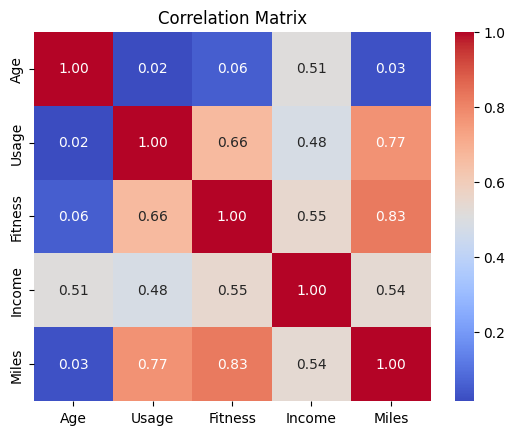

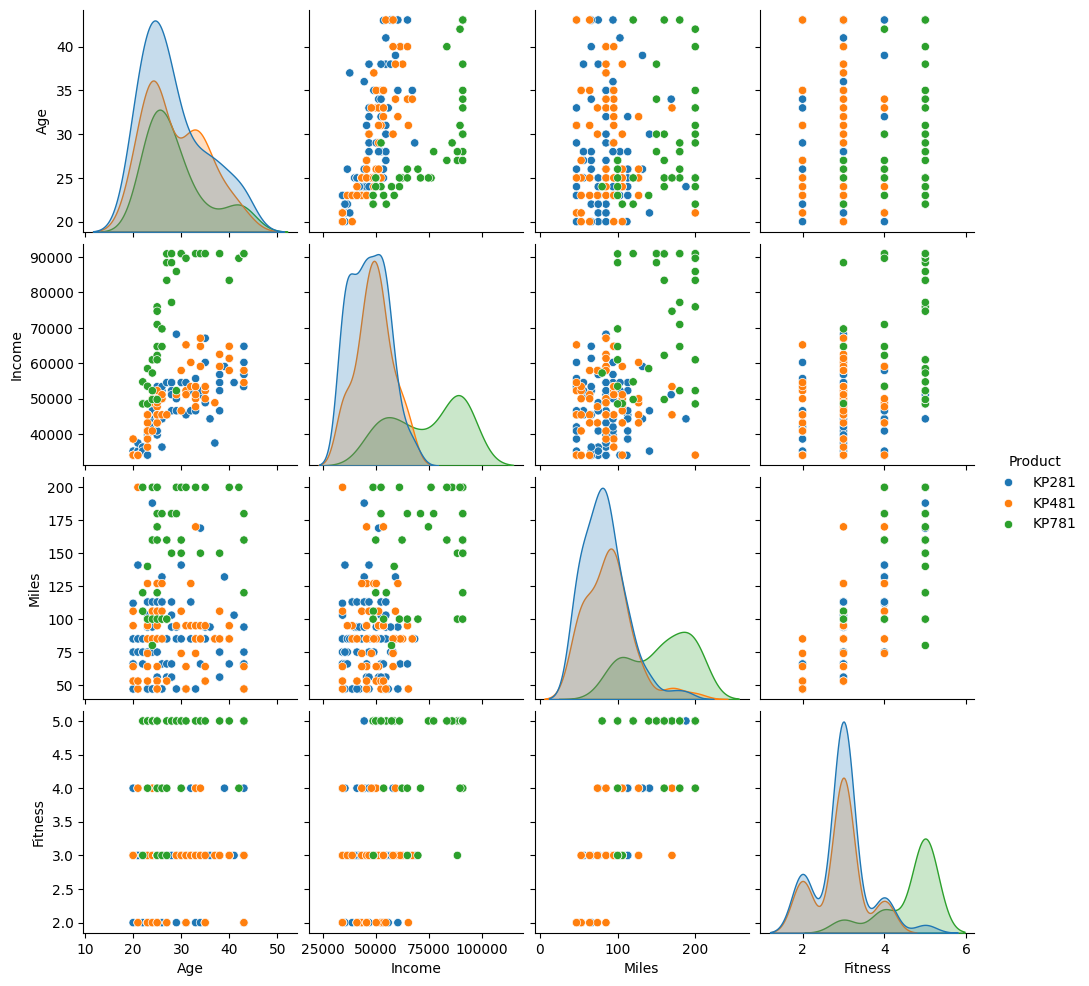

In [ ]:
num_data = data[['Age', 'Usage', 'Fitness', 'Income', 'Miles']]
sns.heatmap(num_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Pairplot for multivariate view
sns.pairplot(data, hue='Product', vars=['Age','Income','Miles','Fitness'])
plt.show()

**6.2 Correlation Insights**

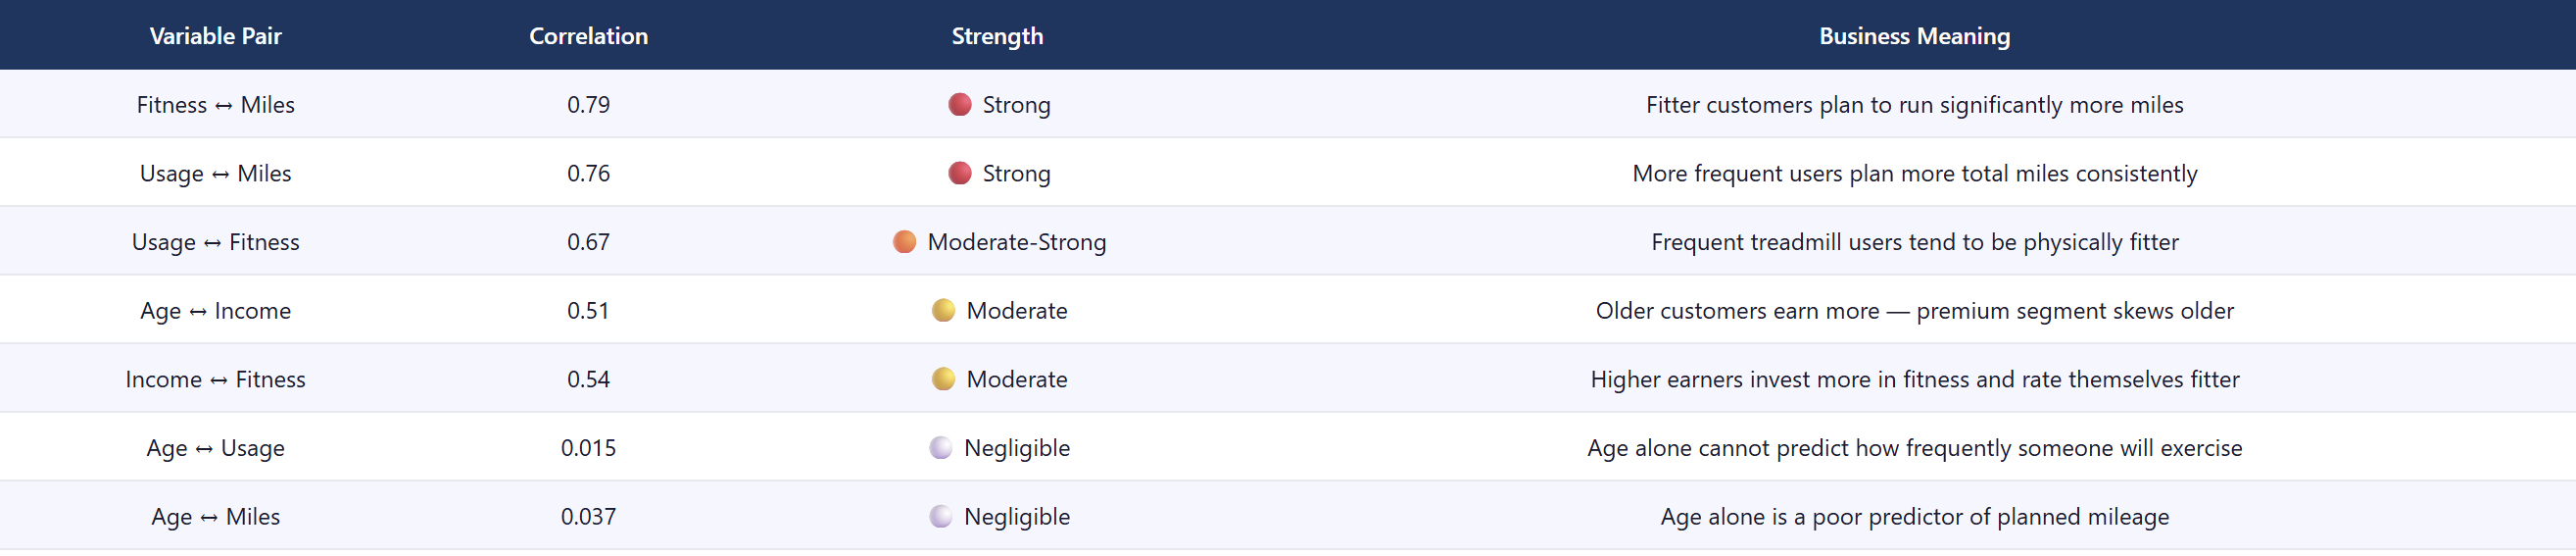

KP281: Entry-level buyers with lower income, lower fitness, and lower planned miles.

KP481: Mid-range buyers with moderate fitness and usage; overlaps strongly with KP281.

KP781: Premium buyers with higher income, higher fitness (4–5), and higher planned miles (100+); this segment is clearly separated.

✅Key business takeaway:

KP781 is the easiest segment to identify, while KP281 and KP481 may require an extra question such as budget or price sensitivity to distinguish between them.

## **7. Customer Profiling**

**7.1 KP281 — Entry Level Profile ($1,500)**

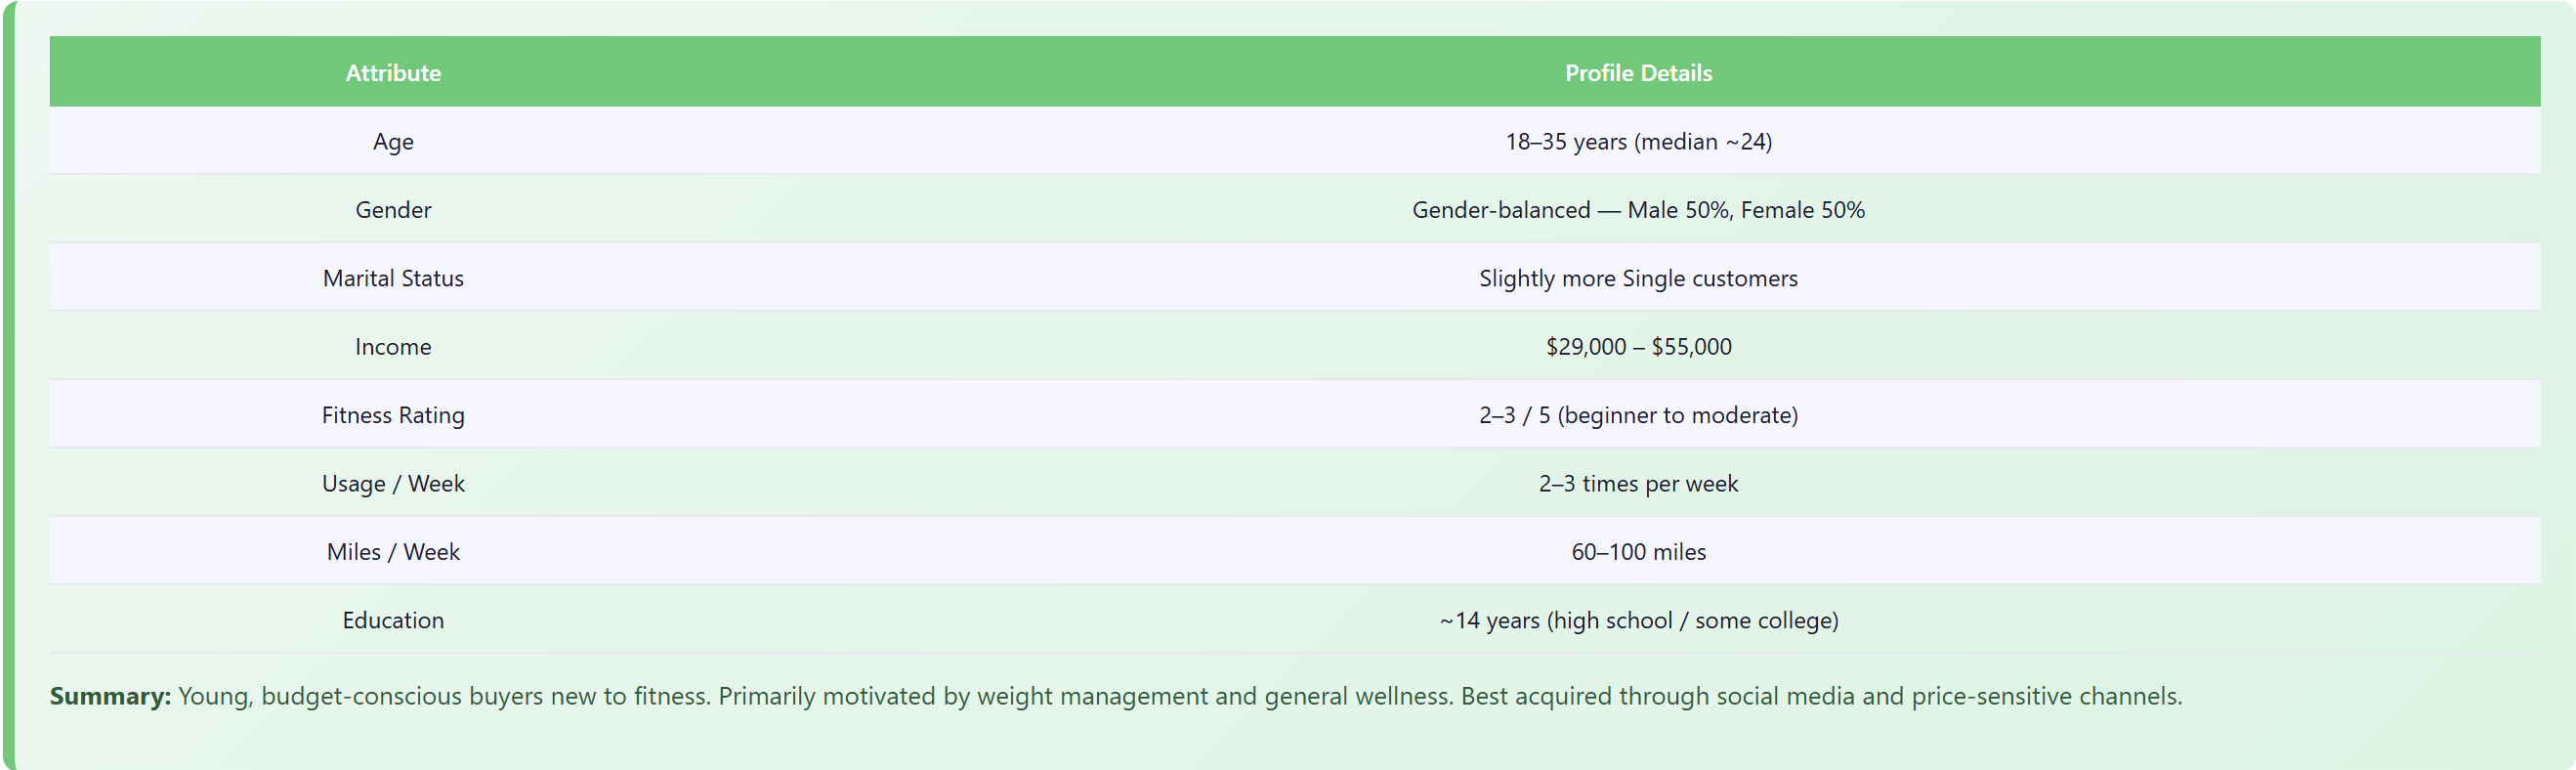

7.2 KP481 — Mid Level Profile ($1,750)

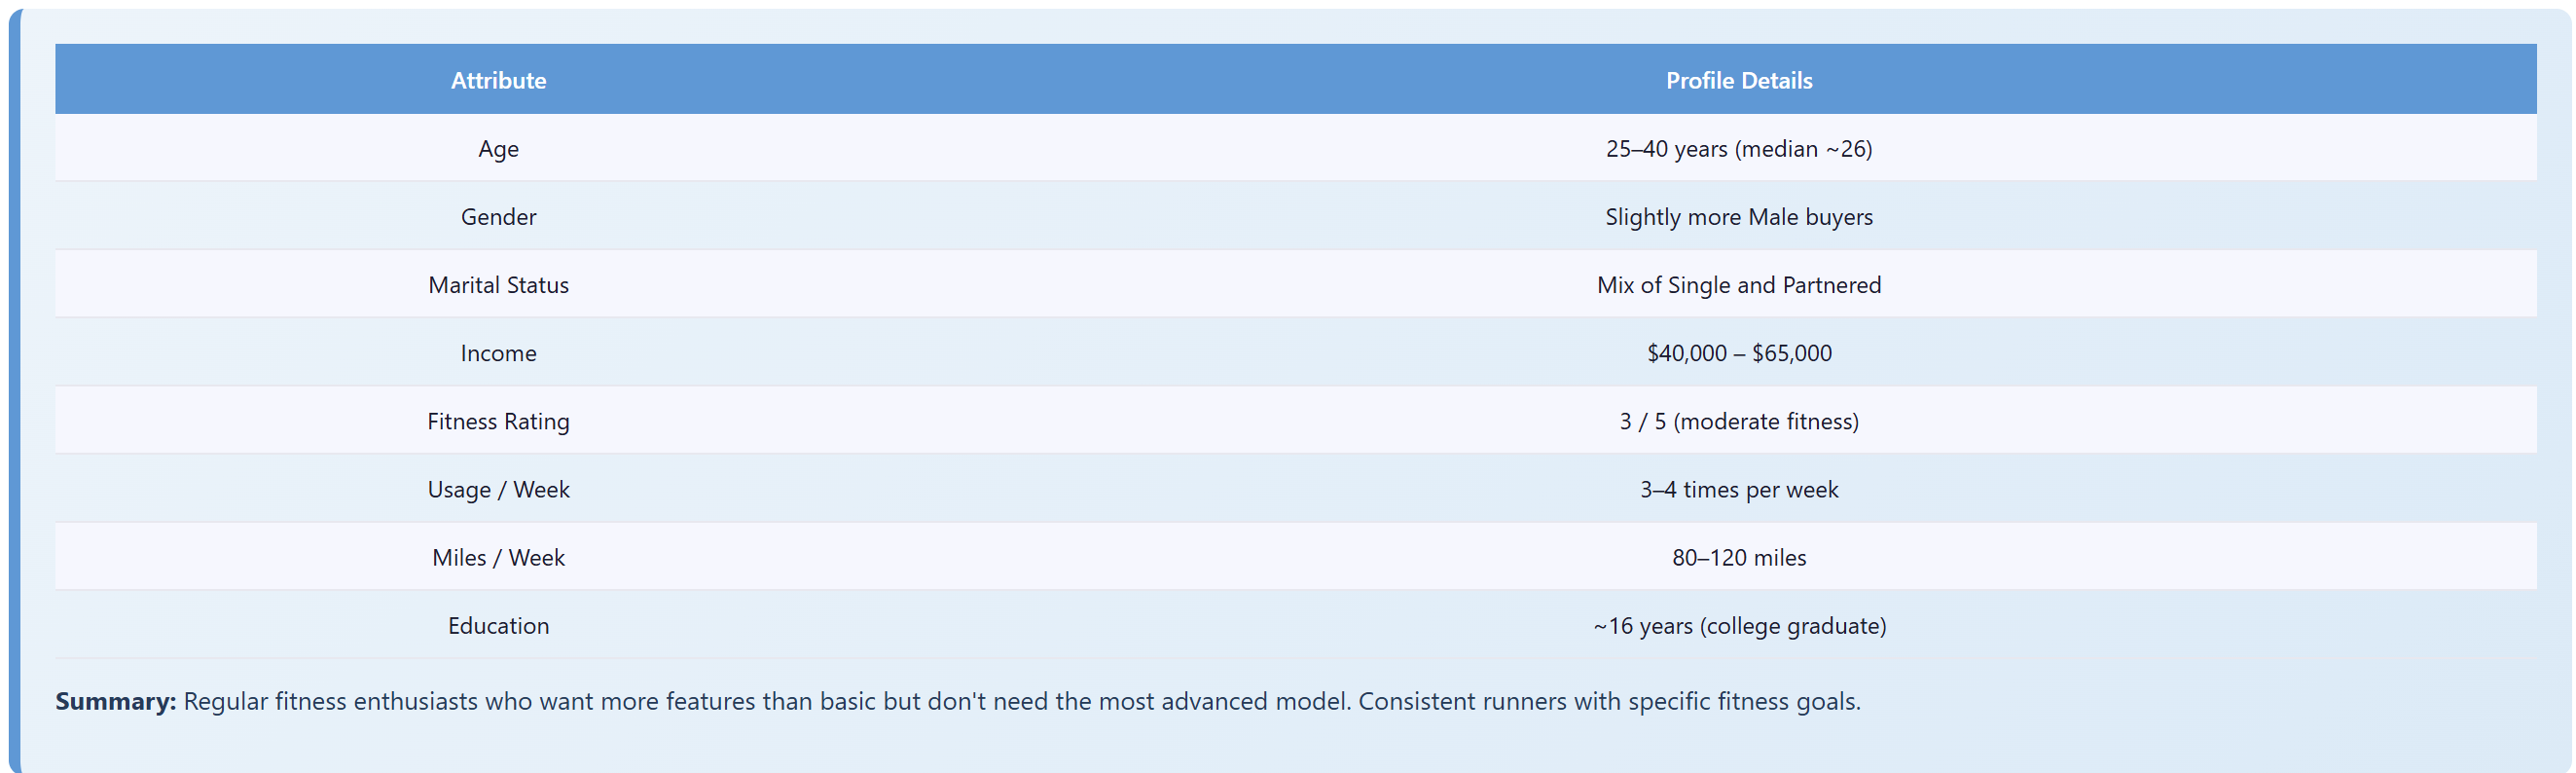

**7.3 KP781 — Premium Level Profile ($2,500)**

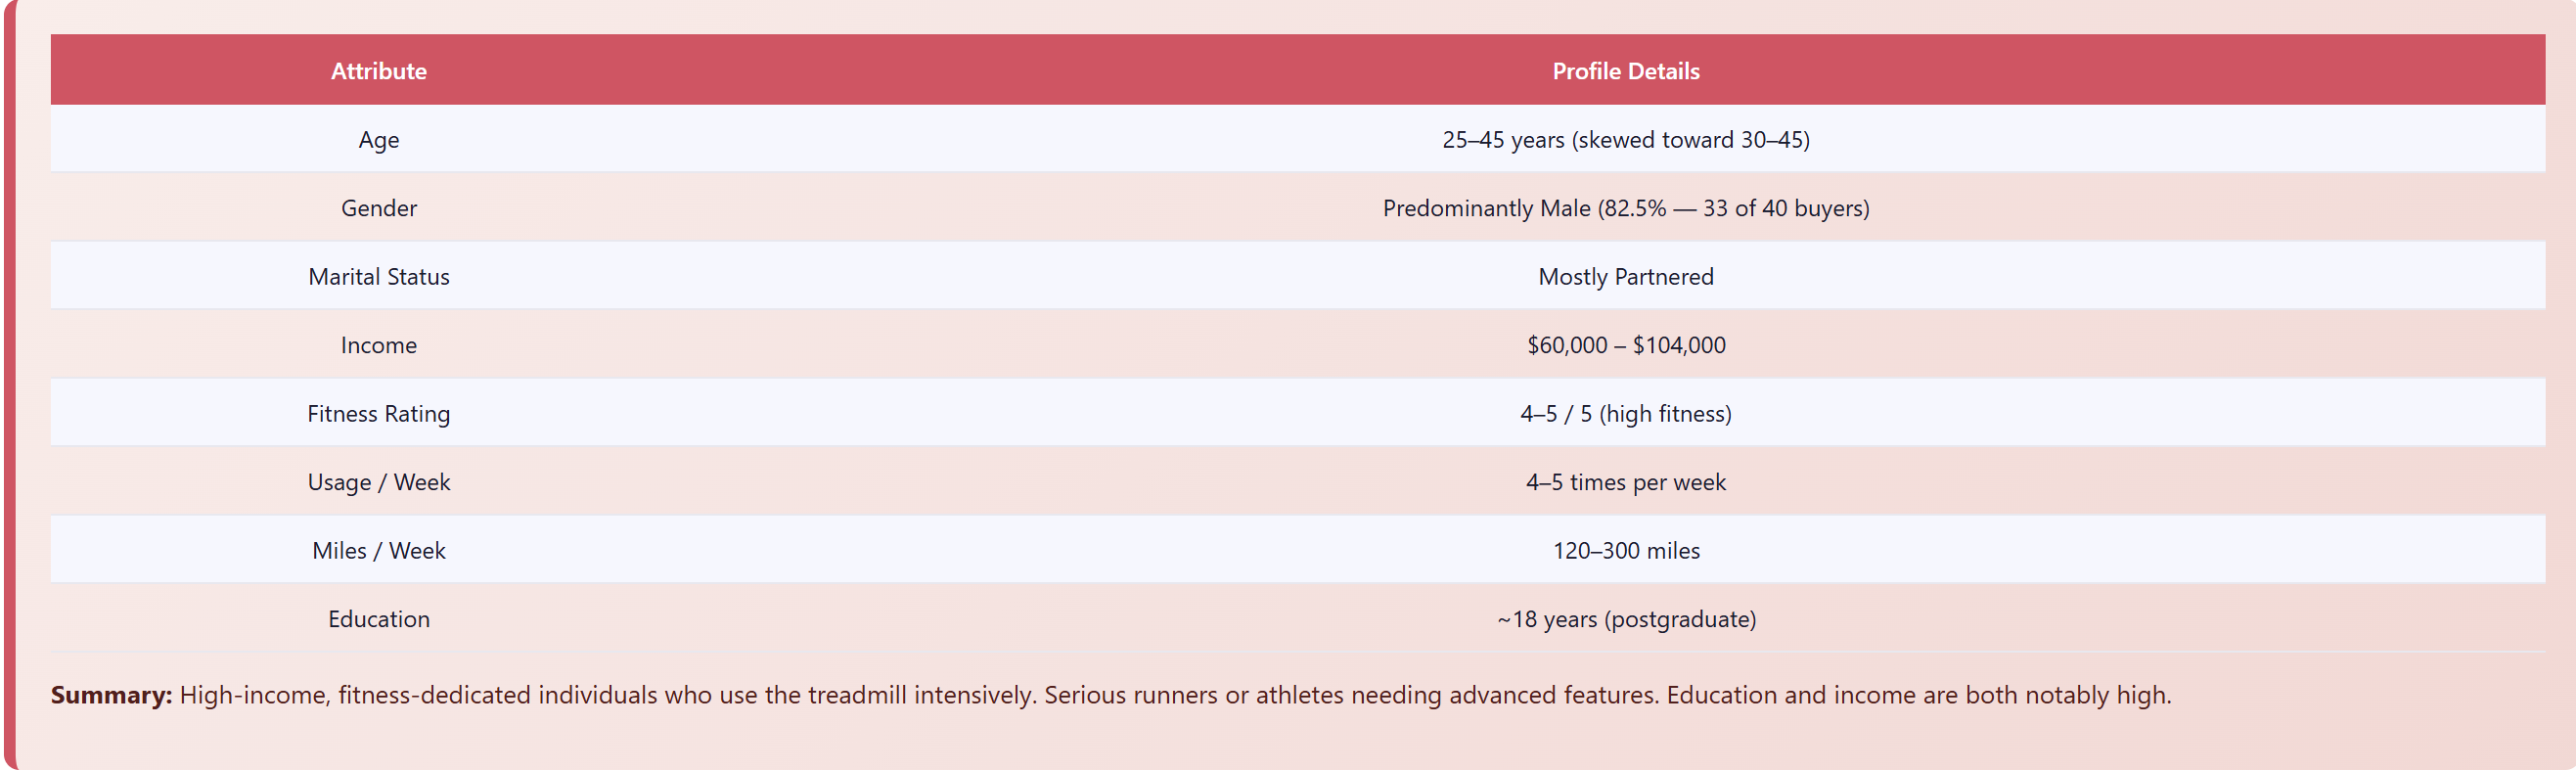

##**8. Business Recommendations**

1. Target KP781 at High-Income Males (30–45)
P(KP781|Male)=31.7% vs P(KP781|Female)=9.2%. Marketing for the premium model should focus on male professionals aged 30–45 earning >$60K. Use channels like LinkedIn, sports media, and business publications.

2. Grow the Female KP781 Segment
Only 7 of 40 KP781 buyers are female — a 3.4× gap vs males. This is a major untapped market. Female-focused campaigns emphasizing performance tracking and health metrics, plus fitness influencer partnerships, could unlock this segment.

3. Use KP281 as a Gateway Product
KP281 holds 44.4% market share. Build a structured upgrade path — track usage data and trigger a personalized KP481/KP781 recommendation when a customer's usage consistently exceeds 4×/week for 3 months.

4. Target Partnered Customers for Premium
P(KP781|Partnered)=26.2% vs P(KP781|Single)=16.4%. Home gym and family fitness promotions ("invest in your family's health") can effectively convert this segment to premium purchases.

5. Build a 3-Question Recommendation System
Fitness, Usage, and Miles are all correlated above 0.67. A simple point-of-sale tool asking these 3 questions can predict product preference with high accuracy and improve conversion rates significantly.

6. Two-Track KP781 Marketing Strategy
KP781 shows bimodal income (55K–65K and 85K+). Create two messages: "Performance Upgrade" for 55K earners (value-focused) and "Elite Fitness" for 85K+ earners (prestige/feature-focused).

**Recommendation Summary Matrix**

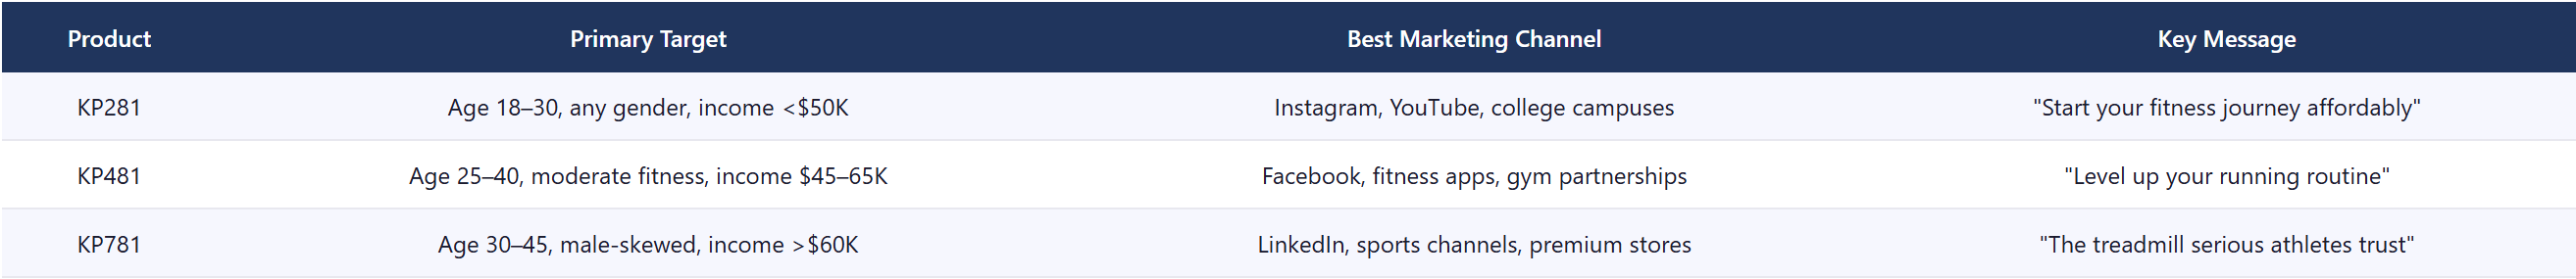

##**9. Conclusion**

**Summary of Key Findings**

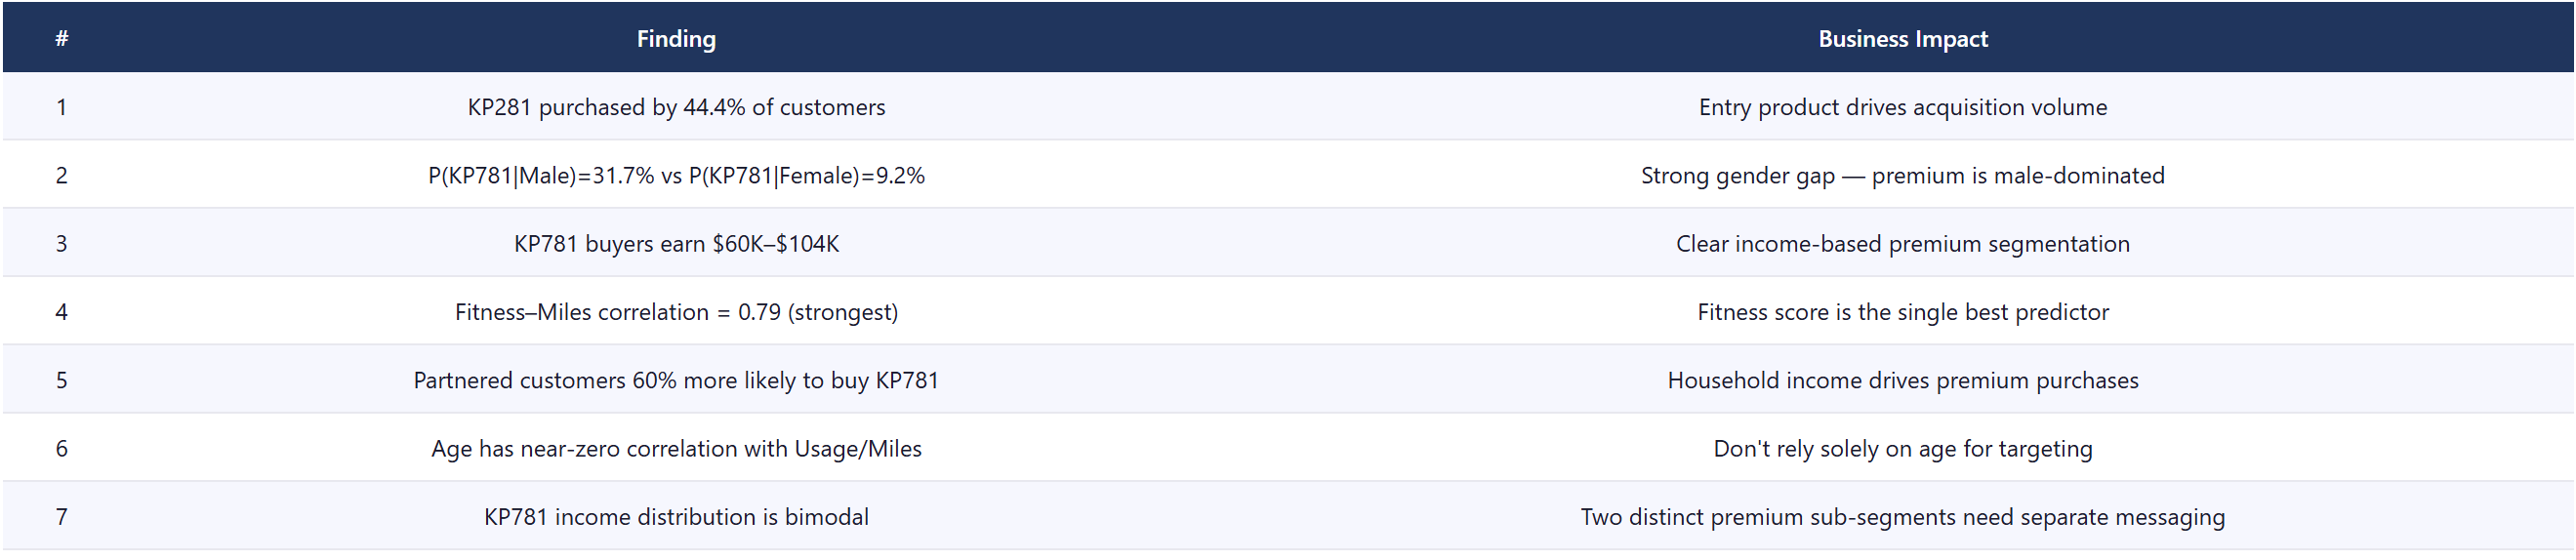

**Final Conclusion**

The data clearly demonstrates that Aerofit's treadmill market is segmented primarily by income, gender, fitness level, and usage habits — not age alone. The strongest predictors of premium (KP781) purchase are high income, male gender, high fitness self-rating, and high planned usage frequency.


Aerofit should invest in a data-driven recommendation system at point-of-sale capturing 3–4 key inputs (fitness rating, income range, planned usage, gender) to instantly recommend the most suitable treadmill. Simultaneously, campaigns to grow the female KP781 segment could significantly expand premium revenue, as this group is underrepresented by a factor of 3.4×.


KP281 should be positioned as a gateway to the Aerofit ecosystem, with structured upgrade paths to KP481 and KP781 based on usage milestones — turning budget buyers into long-term premium customers.